### Example 10 of the PHT3D Manual
The model simulates terminal electron acceptor processes and some secondary reactions as a result of the dissolution of  
the non-aqueous-phase-liquids (NAPLs) toluene and Benzene from a NAPL source zone, and their subsequent biodegradation during groundwater flow and transport. The groundwater flow field is from left to right and non-parallel depending on a heterogenous hydraulic conductivity distribution in the simulated aquifer.

In [11]:
import flopy
import numpy as np
import matplotlib.pyplot as plt

In [3]:
length_units = 'meters'
time_units = 'days'
sim_name = 'ex10' # Note that the name should only contain small letters
gwf_name = f'gwf_{sim_name}'
gwt_name = f'gwt_{sim_name}'
sim_ws = './mf6'
concentration_name = 'concentration' # name for concentration
rtmf6_sol_number_name = 'rtmf6_sol_number' # solution number of PHREEQC solution

In [4]:
sim = flopy.mf6.MFSimulation(sim_name=sim_name, sim_ws=sim_ws)

nper = 1  
perlen = 500 
nstp = 100

In [5]:
tdis = flopy.mf6.ModflowTdis(
    sim, 
    nper=nper, 
    perioddata=[(perlen, nstp, 1.0)], 
    time_units=time_units)

#### Groundwater flow (GWF)

In [6]:
gwf = flopy.mf6.ModflowGwf(
    sim,
    modelname=gwf_name,
    save_flows=True,
    model_nam_file=f"{gwf_name}.nam",
)

In [7]:
#%% Flow solver parameters
nouter, ninner = 300, 600
hclose, rclose, relax = 1e-6, 1e-6, 1.0


imsgwf = flopy.mf6.ModflowIms(
    sim,
    complexity="complex",
    print_option="SUMMARY",
    outer_dvclose=hclose,
    outer_maximum=nouter,
    under_relaxation="NONE",
    inner_maximum=ninner,
    inner_dvclose=hclose,
    rcloserecord=rclose,
    linear_acceleration="CG",
    scaling_method="NONE",
    reordering_method="NONE",
    relaxation_factor=relax,
    filename=f"{gwf_name}.ims",
)
sim.register_ims_package(imsgwf, [gwf.name])

In [8]:
nlay = 1  # Number of layers
ncol = 80 # Number of columns
nrow = 40  # Number of rows
delr = 2.5 # 
delc = 1.25
top = 10
botm = np.array([0])
dis = flopy.mf6.ModflowGwfdis(
    gwf,
    length_units=length_units,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top = top,
    botm = botm,
    filename=f"{gwf_name}.dis",
    nogrb=True,
)

In [9]:
# The hydraulic conductivities are given in K_field.txt,
# extracted from PHT3D User-Interface ORTI3D (https://orti3d.ensegid.fr) 
k11 = np.flipud(np.loadtxt('./K_field.txt')) # the file from ORTI3D is upside-down --> np.flipud

k33 = k11  # Vertical hydraulic conductivity ($m/d$)
icelltype = 1 # saturated thickness varies with computed head when head is below the cell top --> unconfined


npf = flopy.mf6.ModflowGwfnpf(
    gwf,
    save_flows=True,
    save_saturation=True,
    icelltype=icelltype,
    k=k11,
    k33=k33,
    save_specific_discharge=True,
    filename=f"{gwf_name}.npf",
)

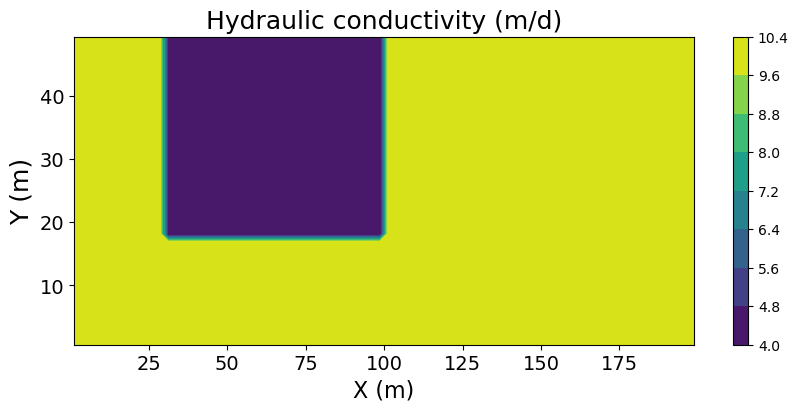

In [18]:
# Show K-field
mg = gwf.modelgrid
x = mg.xcellcenters
y = mg.ycellcenters
plt.figure(figsize=(10,4))
plt.contourf(x,y,k11)
plt.title('Hydraulic conductivity (m/d)',fontsize=18)
plt.colorbar()
plt.xlabel('X (m)',fontsize=16)
plt.ylabel('Y (m)',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [53]:
flopy.mf6.ModflowGwfic(gwf, strt=1, filename=f"{gwf_name}.ic")

package_name = ic
filename = gwf_ex10.ic
package_type = ic
model_or_simulation_package = model
model_name = gwf_ex10

Block griddata
--------------------
strt
{constant 1}



In [54]:
#%% CHD
headup = 5
headdwn = 3
chd_spd = []


auxiliary = [
    concentration_name, # name for concentration
    rtmf6_sol_number_name # solution number of PHREEQC solution
]

for i in range(nrow):
  chd_spd.append([(0, i, 0), headup,0,0])
  chd_spd.append([(0, i, ncol-1), headdwn,0,0])

chd = flopy.mf6.ModflowGwfchd(
    gwf,
    maxbound=len(chd_spd),
    stress_period_data=chd_spd,
    save_flows=False,
    auxiliary=auxiliary,
    pname="CHD",
    filename=f"{gwf_name}.chd",
)

In [55]:
oc_gwf = flopy.mf6.ModflowGwfoc(
    gwf,
    head_filerecord=f"{gwf_name}.hds",
    budget_filerecord=f"{gwf_name}.cbb",
    headprintrecord=[("COLUMNS", 10, "WIDTH", 15, "DIGITS", 6, "GENERAL")],
    saverecord=[("HEAD", "ALL"), ("BUDGET", "ALL")],
    printrecord=[("HEAD", "LAST"), ("BUDGET", "LAST")],
)

#### Transport (GWT)

In [56]:
gwt = flopy.mf6.MFModel(
    sim,
    model_type="gwt6",
    modelname=gwt_name,
    model_nam_file=f"{gwt_name}.nam"
)

In [57]:
#%% Transport solver parametersk11 = np.flipud(np.loadtxt('./K_field.txt'))
imsgwt = flopy.mf6.ModflowIms(
    sim,
    print_option="SUMMARY",
    outer_dvclose=hclose,
    outer_maximum=nouter,
    under_relaxation="NONE",
    inner_maximum=ninner,
    inner_dvclose=hclose,
    rcloserecord=rclose,
    linear_acceleration="BICGSTAB",
    scaling_method="NONE",
    reordering_method="NONE",
    relaxation_factor=relax,
    filename=f"{gwt_name}.ims",
)
sim.register_ims_package(imsgwt, [gwt.name])

In [58]:
gwt_dis = flopy.mf6.ModflowGwtdis(
    gwt,
    length_units=length_units,
    nlay=nlay,
    nrow=nrow,
    ncol=ncol,
    delr=delr,
    delc=delc,
    top = top,
    botm = botm,
    filename=f"{gwt_name}.dis",
    nogrb=True,
)

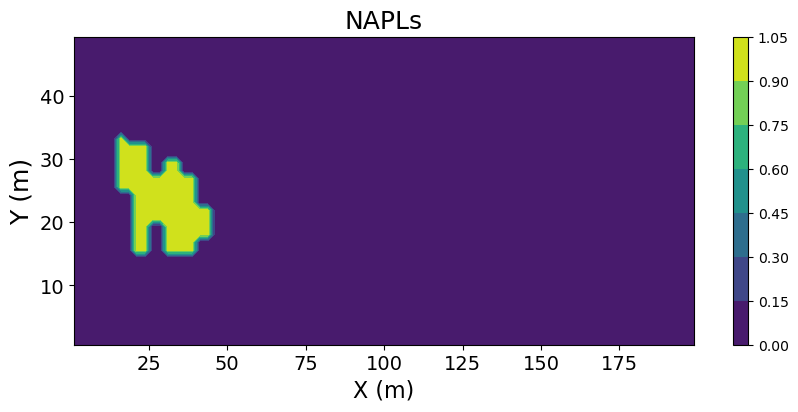

In [19]:
#%% NAPLs
## The distribution of the solution containing the NAPLs is given in NAPL.txt,
## extracted from PHT3D User-Interface ORTI3D (https://orti3d.ensegid.fr) 
## The solution present the initial concentrations of the immobile NAPL components toluene and benzene defined as KINETIC reactants
## in phreeqc. 

napl = np.flipud(np.loadtxt('./NAPL.txt')) # the file from ORTI3D is upside-down --> np.flipud

# Show NAPL
mg = gwf.modelgrid
x = mg.xcellcenters
y = mg.ycellcenters
plt.figure(figsize=(10,4))
plt.contourf(x,y,napl)
plt.title('NAPLs',fontsize=18)
plt.colorbar()
plt.xlabel('X (m)',fontsize=16)
plt.ylabel('Y (m)',fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [59]:
#%% Transport IC

## Uncommenting the following lines produce the corresponing rtmf6 initial condition file for kinetics to be placed as 
## init_kinetics.ic in the directory rtmf6

#gwt_ic = flopy.mf6.ModflowGwtic(
#    gwt, 
#    strt=napl,  # rtmf6 solution number
#    filename=f"{gwt_name}.ic")

## Otherwise the follwing lines will produce the initial solution file:

gwt_ic = flopy.mf6.ModflowGwtic(
    gwt, 
    strt=0,  # rtmf6 solution number
    filename=f"{gwt_name}.ic")

In [60]:
#%% Transport SSM
sourcerecarray = ['CHD', 'aux', concentration_name]

ssm = flopy.mf6.ModflowGwtssm(
    gwt, 
    sources=sourcerecarray, 
    save_flows=True,
    print_flows=True,
    filename=f"{gwt_name}.ssm"
)

In [61]:
adv = flopy.mf6.ModflowGwtadv(
    gwt,
    scheme="UPSTREAM",
)

In [62]:
dispersivity = 0.5
transverse_horizontal_dispersivity = dispersivity * 0.2
transverse_vertical_dispersivity = dispersivity * 0.1

dsp = flopy.mf6.ModflowGwtdsp(
            gwt,
            xt3d_off=True,
            alh=dispersivity,
            ath1=transverse_horizontal_dispersivity,
            atv=transverse_vertical_dispersivity, 
            filename=f"{gwt_name}.dsp",
        )

In [63]:
first_order_decay = None
porosity = 0.3

mst = flopy.mf6.ModflowGwtmst(
    gwt,
    porosity=porosity,
    first_order_decay=first_order_decay,
    filename=f"{gwt_name}.mst",
)

In [64]:
oc_gwt = flopy.mf6.ModflowGwtoc(
    gwt,
    budget_filerecord=f"{gwt_name}.cbb",
    concentration_filerecord=f"{gwt_name}.ucn",
    concentrationprintrecord=[
        ("COLUMNS", 10, "WIDTH", 15, "DIGITS", 10, "GENERAL")
    ],
    saverecord=[("CONCENTRATION", "ALL"), 
                ("BUDGET", "ALL")
                ],
    printrecord=[("CONCENTRATION", "ALL"), 
                 ("BUDGET", "ALL")
                    ],
)

In [65]:
#%% GWF-GWT Exchange
flopy.mf6.ModflowGwfgwt(
    sim,
    exgtype="GWF6-GWT6",
    exgmnamea=gwf_name,
    exgmnameb=gwt_name,
    filename=f"{sim_name}.gwfgwt",
)

package_name = ex10.gwfgwt
filename = ex10.gwfgwt
package_type = gwfgwt
model_or_simulation_package = simulation
simulation_name = ex10


In [66]:
# writing the MF6 files to be used as templates for the RTMF6 input, such as initial conditions 
sim.write_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package ims_-1...
  writing solution package ims_0...
  writing package ex10.gwfgwt...
  writing model gwf_ex10...
    writing model name file...
    writing package dis...
    writing package npf...
    writing package ic...
    writing package chd...
    writing package oc...
  writing model gwt_ex10...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package ssm...
    writing package adv...
    writing package dsp...
    writing package mst...
    writing package oc...
